Assignment 1 — Build Linear Regression From Scratch (No sklearn)
Implement Linear Regression using Gradient Descent from scratch.
Dataset
Use California Housing Dataset or Boston Housing Dataset (alternative).
Participants may download from:
Kaggle or sklearn datasets
Tasks
1. Load dataset using pandas.
2. Perform data exploration.
3. Handle:
missing values
outliers
4. Normalize features using StandardScaler logic (manual).
5. Implement Linear Regression from scratch:
initialize weights
implement cost function (MSE)
implement gradient descent
6. Train model for multiple learning rates.
7. Plot cost vs iterations.
8. Compare results with sklearn LinearRegression.
Deliverables
Participants must show:
MAE
MSE
RMSE
R²
comparison with sklearn model
Also try:
Implement Stochastic Gradient Descent (SGD) version.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('California_Housing.csv')
# Display first 5 rows
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Check missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.0000

In [5]:
df.fillna({'total_bedrooms': df['total_bedrooms'].mean()}, inplace=True)

In [6]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [7]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [8]:
X_mean = X.mean()
X_std = X.std()

X_scaled = (X - X_mean) / X_std

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled.values, y.values, test_size=0.2, random_state=42
)

In [10]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):
            y_pred = np.dot(X, self.weights) + self.bias

            # Gradients
            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            # Update weights
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Cost
            cost = self.mse(y, y_pred)
            self.cost_history.append(cost)

            # Print progress
            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {cost}")

            # Stop if divergence
            if np.isnan(cost):
                print("Training stopped due to NaN")
                break

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

Iteration 0, Cost: 56297423231.03131
Iteration 100, Cost: 38742406090.651695
Iteration 200, Cost: 27307259380.67292
Iteration 300, Cost: 19813779404.88682
Iteration 400, Cost: 14879747192.951677
Iteration 0, Cost: 56297423231.03131
Iteration 100, Cost: 5929073799.143705
Iteration 200, Cost: 4996341978.001773
Iteration 300, Cost: 4905390608.983614
Iteration 400, Cost: 4855525254.10855
Iteration 0, Cost: 56297423231.03131
Iteration 100, Cost: 4742172351.040455
Iteration 200, Cost: 4700914684.217179
Iteration 300, Cost: 4689824645.505499
Iteration 400, Cost: 4685945527.160559


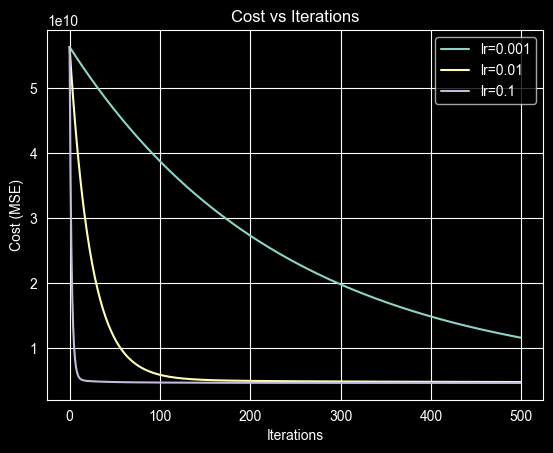

In [11]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure()

for lr in learning_rates:
    model = LinearRegressionGD(lr=lr, iterations=500)
    model.fit(X_train, y_train)
    plt.plot(model.cost_history, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

In [12]:
model = LinearRegressionGD(lr=0.01, iterations=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Iteration 0, Cost: 56297423231.03131
Iteration 100, Cost: 5929073799.143705
Iteration 200, Cost: 4996341978.001773
Iteration 300, Cost: 4905390608.983614
Iteration 400, Cost: 4855525254.10855
Iteration 500, Cost: 4821194862.482389
Iteration 600, Cost: 4796364369.892735
Iteration 700, Cost: 4777732544.653691
Iteration 800, Cost: 4763306462.800373
Iteration 900, Cost: 4751840998.832342


In [13]:
def evaluate(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    r2 = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

    return mae, mse, rmse, r2

mae, mse, rmse, r2 = evaluate(y_test, y_pred)

print("Gradient Descent Model")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Gradient Descent Model
MAE: 50591.38750920381
MSE: 4910447656.032469
RMSE: 70074.58637789072
R2 Score: 0.6252736559677513


In [14]:
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

y_sk = sk_model.predict(X_test)

mae_s, mse_s, rmse_s, r2_s = evaluate(y_test, y_sk)

print("\nSklearn Model")
print("MAE:", mae_s)
print("MSE:", mse_s)
print("RMSE:", rmse_s)
print("R2 Score:", r2_s)


Sklearn Model
MAE: 50701.779031329934
MSE: 4904399775.949276
RMSE: 70031.41991955665
R2 Score: 0.6257351821159705


In [15]:
class LinearRegressionSGD:
    def __init__(self, lr=0.0001, epochs=50):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            for i in range(n_samples):
                xi = X[i]
                yi = y[i]

                y_pred = np.dot(xi, self.weights) + self.bias

                error = yi - y_pred

                # Gradients
                dw = -2 * xi * error
                db = -2 * error

                # Gradient clipping (IMPORTANT)
                dw = np.clip(dw, -1, 1)
                db = np.clip(db, -1, 1)

                # Update
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias